In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

In [32]:
df = pd.read_csv("employee_income.csv")
df.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


In [33]:
df.isnull().sum()

age           0
experience    0
income        0
dtype: int64

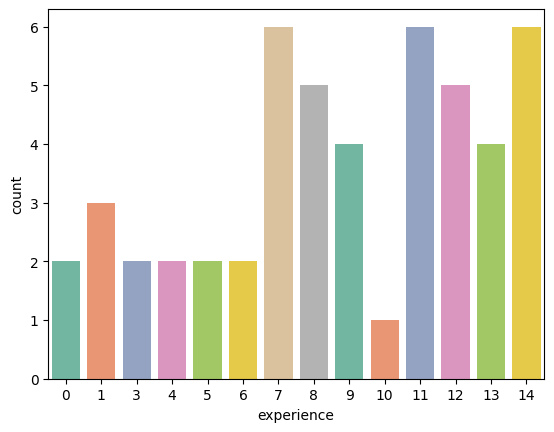

In [34]:
sns.countplot(
    data=df,
    x="experience",
    palette="Set2"
)
plt.show()

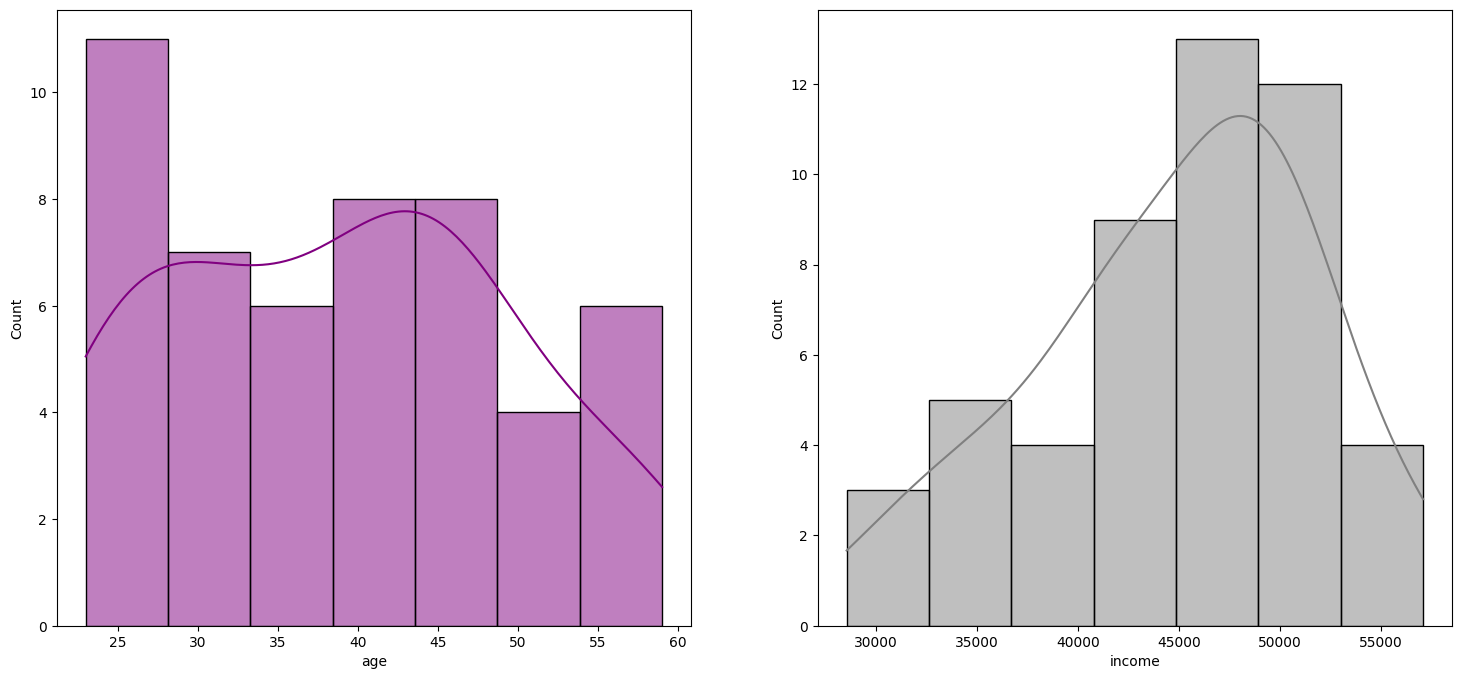

In [14]:
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)
sns.histplot(
    data=df,
    x="age",
    color="purple",
    kde=True
)

plt.subplot(1,2,2)
sns.histplot(
    data=df,
    x="income",
    color="gray",
    kde=True
)
plt.show()

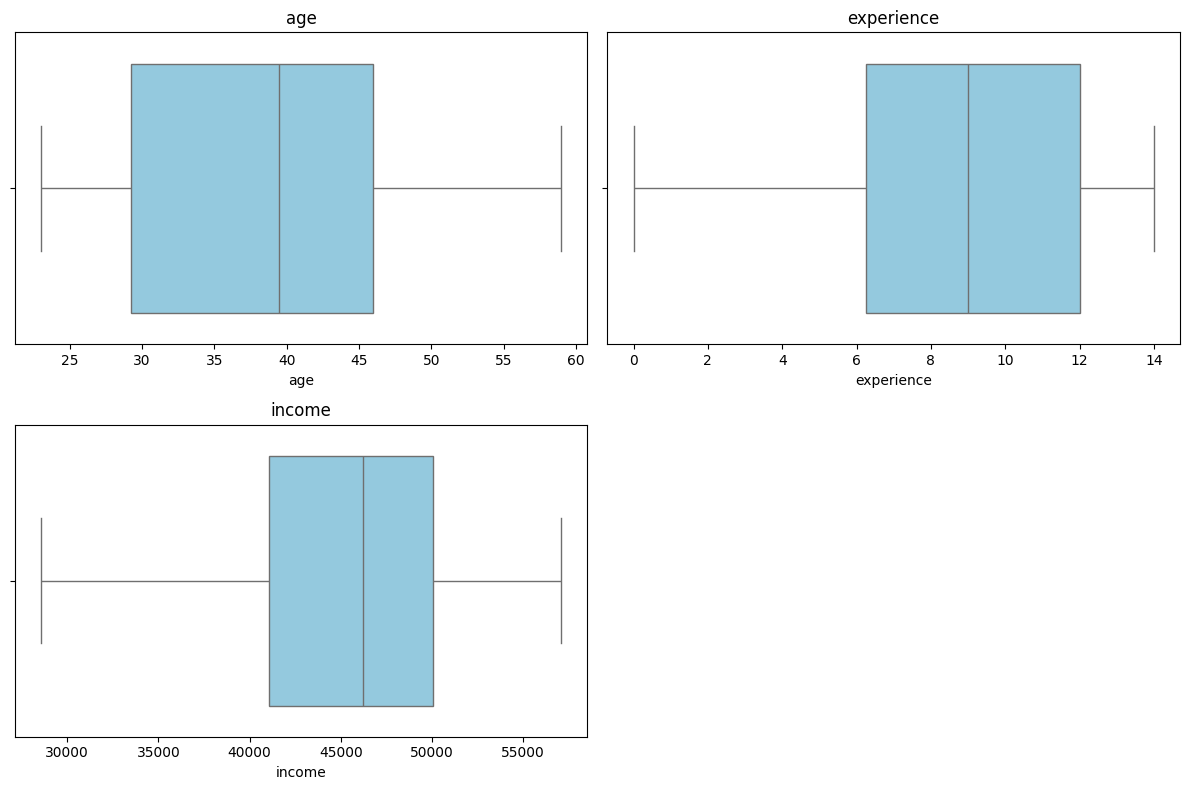

In [15]:
cols = df.columns
n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i],
        color="skyblue"
    )
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


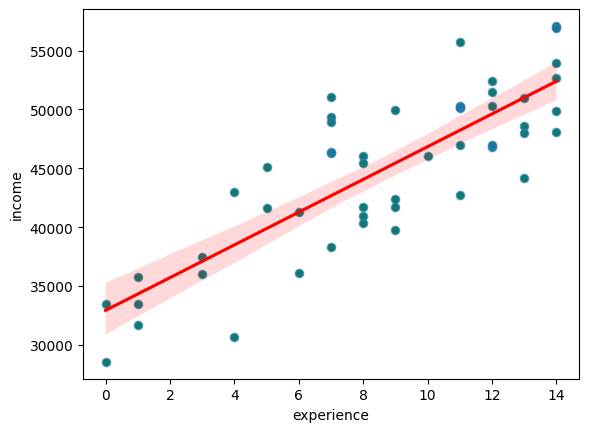

In [16]:
sns.scatterplot(
    data=df,
    x="experience",
    y="income",
    color="green"
)
sns.regplot(
    data=df,
    x="experience",
    y="income",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.show()

In [30]:


X = df.drop("income",axis=1)
y = df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test,y_pred)

print("Score --> ",score),
print("MAE --> ",mae),
print("MSE --> ",mse)
print("RMSE --> ",rmse)

Score -->  0.9349274275513149
MAE -->  1581.4121026423527
MSE -->  3061367.4513883768
RMSE -->  1749.6763847604439


In [36]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
# Keep employee_income.csv in same folder

df = pd.read_csv("employee_income.csv")

# Features and target
X = df.drop("income", axis=1)
y = df["income"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LinearRegression()

# Train model
model.fit(X_train_scaled, y_train)

# Prediction
pred = model.predict(X_test_scaled)

# Accuracy
score = r2_score(y_test, pred)
print("Model Score:", score)

# Save model and scaler
joblib.dump(model, "salary_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Score: 0.9349274275513151
Model Saved Successfully
